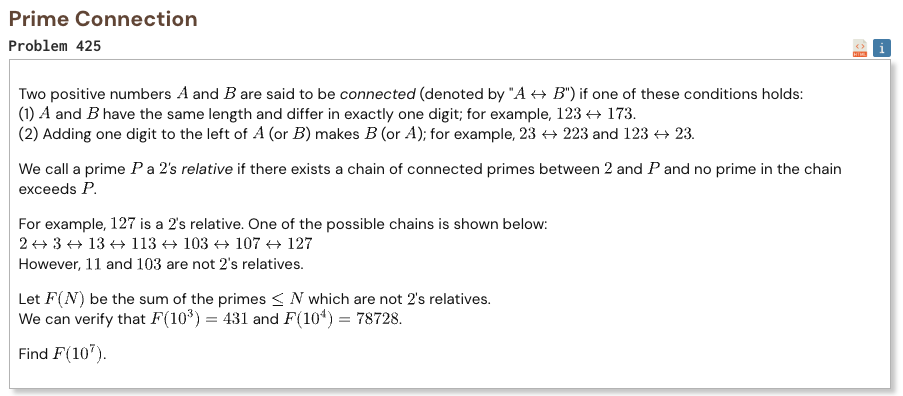

## Initial approach

-   generate every prime up to ten million with a sieve
-   think of each prime as a node and connect primes that satisfy the digit rules
-   process the primes from smallest to largest
-   when a prime appears connect it only to smaller prime neighbours that were already processed
-   use a disjoint set structure to keep track of which primes are connected to each other
-   a prime is a relative of two exactly when it belongs to the same connected group as two at that moment
-   add the primes that are still disconnected from two to the final sum

In [1]:
def prime_sieve(limit):
    is_prime = bytearray(b"\x01") * (limit + 1)
    is_prime[0:2] = b"\x00\x00"

    p = 2

    while p * p <= limit:
        if is_prime[p]:
            is_prime[p * p:limit + 1:p] = b"\x00" * (
                (limit - p * p) // p + 1
            )

        p += 1

    primes = [i for i in range(2, limit + 1) if is_prime[i]]

    return is_prime, primes


class DSU:
    def __init__(self, n):
        self.parent = list(range(n + 1))
        self.size = [1] * (n + 1)

    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]

        return x

    def union(self, a, b):
        a = self.find(a)
        b = self.find(b)

        if a == b:
            return

        if self.size[a] < self.size[b]:
            a, b = b, a

        self.parent[b] = a
        self.size[a] += self.size[b]


def smaller_neighbours(n, is_prime):
    neighbours = []
    power = 1
    temp = n

    while temp > 0:
        digit = (n // power) % 10
        prefix = n // (power * 10)

        for new_digit in range(digit):
            if prefix == 0 and new_digit == 0:
                continue

            candidate = n + (new_digit - digit) * power

            if candidate >= 2 and is_prime[candidate]:
                neighbours.append(candidate)

        power *= 10
        temp //= 10

    power //= 10

    if power >= 10:
        candidate = n % power

        if candidate >= power // 10 and is_prime[candidate]:
            neighbours.append(candidate)

    return neighbours


def solve(limit):
    is_prime, primes = prime_sieve(limit)
    dsu = DSU(limit)

    result = 0

    for p in primes:
        for q in smaller_neighbours(p, is_prime):
            dsu.union(p, q)

        if dsu.find(p) != dsu.find(2):
            result += p

    return result

In [2]:
%%time
result = solve(10**7)
print("Result:", result)

Result: 46479497324
CPU times: user 2.94 s, sys: 79.5 ms, total: 3.02 s
Wall time: 3.03 s
